# Regresión Lineal con Redes Neuronales
**Dataset:** California Housing

En este notebook voy a usar una red neuronal para hacer regresión lineal. La idea que tengo es predecir el precio de casas en California usando datos como el ingreso de la zona, cuántos cuartos tienen las casas, etc.

Aparte voy a mostrar qué pasa cuando el modelo aprende muy poco (underfitting) y que pasa cuando aprende demasiado (overfitting).

---
## 1 - Preparacion de los datos

In [6]:
# Importamos todas las librerias y dependencias necesarias 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras

# Esto es para que los resultados sean iguales cada vez que corro el notebook
np.random.seed(42)
tf.random.set_seed(42)



I0000 00:00:1776030835.106369    1919 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776030853.393338    1919 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776030863.402056    1919 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [7]:
# Importo el dataset de california housing que viene incluido en sklearn
datos = fetch_california_housing()

X = datos.data    # las variables de entrada (ingreso, habitaciones, etc)
y = datos.target  # lo que quiero predecir (precio de la casa)

print("forma de X:", X.shape)
print("forma de y:", y.shape)
print("\nColumnas:", datos.feature_names)
print("\nprimeros 5 valores del precio:", y[:5])

forma de X: (20640, 8)
forma de y: (20640,)

Columnas: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

primeros 5 valores del precio: [4.526 3.585 3.521 3.413 3.422]


---
El dataset tiene 20,640 casas con 8 características cada una. El precio está en cientos de miles de dólares.

Las 8 características son:
- MedInc: ingreso mediano de la zona
- HouseAge: edad de las casas
- AveRooms: promedio de habitaciones
- AveBedrms: promedio de dormitorios
- Population: población del bloque
- AveOccup: promedio de ocupantes
- Latitude y Longitude: ubicación geográfica

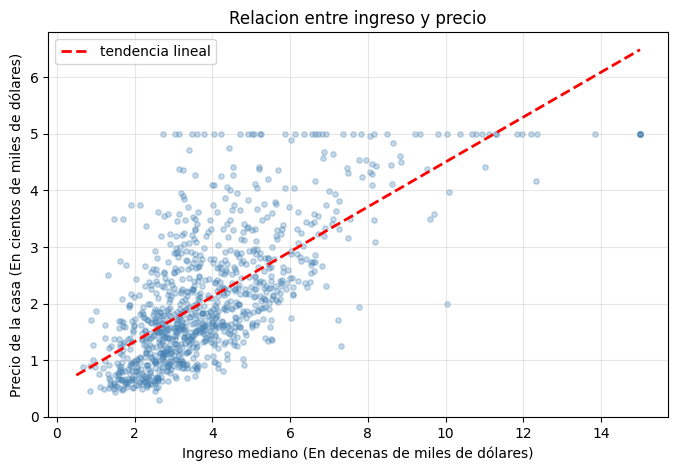

la linea roja muestra la tendencia lineal positiva entre ingreso y precio


In [8]:
muestra = np.random.choice(len(X), 1000, replace=False)

plt.figure(figsize=(8, 5))
plt.scatter(X[muestra, 0], y[muestra], alpha=0.3, color='steelblue', s=15)

# Linea de tendencia
m, b = np.polyfit(X[muestra, 0], y[muestra], 1)
x_linea = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
plt.plot(x_linea, m * x_linea + b, color='red', linewidth=2, 
         linestyle='--', label='tendencia lineal')

plt.xlabel('Ingreso mediano (En decenas de miles de dólares)')
plt.ylabel('Precio de la casa (En cientos de miles de dólares)')
plt.title('Relacion entre ingreso y precio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("la linea roja muestra la tendencia lineal positiva entre ingreso y precio")

In [9]:
# Division en entrenamiento y prueba (80% para entrenar, 20% para probar)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizo los datos para que la red neuronal aprenda mejor
# esto hace que todos los valores tengan media 0 y desviacion 1
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("datos de entrenamiento:", X_train.shape)
print("datos de prueba:", X_test.shape)

datos de entrenamiento: (16512, 8)
datos de prueba: (4128, 8)


---
## 2 - Modelo bien entrenado

Primero la construccion de la red neuronal. La arquitectura es simple: unas capas ocultas y una capa de salida con 1 neurona (sin función de activación) porque es regresión, no clasificación.

Esta misma arquitectura la voy a usar en los 3 modelos, lo único que cambia es con cuántas épocas la entreno.

In [10]:
# Funcion para construir el modelo, asi evito repetir el codigo a lo largo del proceso de entrenamiento
def crear_modelo():
    modelo = keras.Sequential([
        keras.layers.Input(shape=(8,)),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(16, activation='relu'),
        keras.layers.Dense(1)
    ])

    modelo.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return modelo

# muestro como se ve el modelo
modelo_prueba = crear_modelo()
modelo_prueba.summary()

E0000 00:00:1776030865.246329    1919 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Modelo bien entrenado con 100 epocas
# 100 epocas es suficiente para que aprenda sin memorizar
modelo_bueno = crear_modelo()

historia_bueno = modelo_bueno.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/100


516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.7324 - mae: 0.5868 - val_loss: 0.4087 - val_mae: 0.4532
Epoch 2/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3791 - mae: 0.4364 - val_loss: 0.3709 - val_mae: 0.4313
Epoch 3/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3514 - mae: 0.4191 - val_loss: 0.3496 - val_mae: 0.4183
Epoch 4/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3333 - mae: 0.4062 - val_loss: 0.3347 - val_mae: 0.4074
Epoch 5/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3207 - mae: 0.3963 - val_loss: 0.3296 - val_mae: 0.3997
Epoch 6/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3133 - mae: 0.3902 - val_loss: 0.3215 - val_mae: 0.3934
Epoch 7/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3042 - mae: 0.3836 - val_loss: 0.3144 - val_mae: 0.3886
Epoch 8/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2986 - mae: 0.3792 - val_loss: 0.3090 - val_mae: 0.3866
Epoch 9/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss:

In [12]:
# Prueba del modelo bien entrenado
predicciones_bueno = modelo_bueno.predict(X_test).flatten()

mse_bueno = mean_squared_error(y_test, predicciones_bueno)
r2_bueno = r2_score(y_test, predicciones_bueno)

print("Resultados del modelo bien entrenado:")
print(f"  MSE: {mse_bueno:.4f}")
print(f"  R2:  {r2_bueno:.4f}")
print(f"\nEl modelo explica el {r2_bueno*100:.1f}% de la variabilidad del precio")

  1/129 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 841us/step
Resultados del modelo bien entrenado:
  MSE: 0.2719
  R2:  0.7925

El modelo explica el 79.3% de la variabilidad del precio


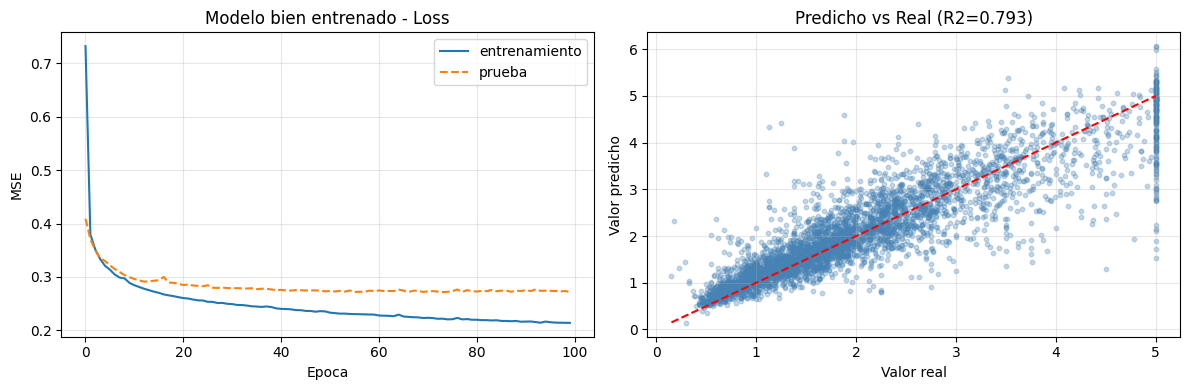

Las dos curvas bajan juntas y se estabilizan, una señal de que el modelo está bien entrenado y no memoriza


In [13]:
# Graficas de las curvas de aprendizaje
# Si el modelo está bien entrenado, las dos curvas bajaran juntas y estabilizarse
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(historia_bueno.history['loss'], label='entrenamiento')
plt.plot(historia_bueno.history['val_loss'], label='prueba', linestyle='--')
plt.title('Modelo bien entrenado - Loss') #Curva de perdida (MSE) durante el entrenamiento
plt.xlabel('Epoca')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_test, predicciones_bueno, alpha=0.3, s=10, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title(f'Predicho vs Real (R2={r2_bueno:.3f})') #Variabilidad en el precio de las casas.
plt.xlabel('Valor real')
plt.ylabel('Valor predicho')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Las dos curvas bajan juntas y se estabilizan, una señal de que el modelo está bien entrenado y no memoriza")

---
## 3 - Modelo subentrenado (Underfitting)

Ahora voy a entrenar el mismo modelo pero con muy pocas épocas (solo 5). El modelo no va a tener suficiente tiempo para aprender y va a quedar con un error alto tanto en entrenamiento como en prueba.

Basicamente eso es underfitting: El modelo es demasiado "flojo" para aprender los patrones y dar un buen resultado.

In [14]:
# Modelo subentrenado: misma arquitectura pero solo 5 epocas
modelo_under = crear_modelo()

historia_under = modelo_under.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

print("\ncon solo 5 epocas el modelo no alcanza a aprender bien")

Epoch 1/5


516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8606 - mae: 0.6291 - val_loss: 0.4033 - val_mae: 0.4513
Epoch 2/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3760 - mae: 0.4349 - val_loss: 0.3647 - val_mae: 0.4297
Epoch 3/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3512 - mae: 0.4184 - val_loss: 0.3493 - val_mae: 0.4161
Epoch 4/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3332 - mae: 0.4059 - val_loss: 0.3376 - val_mae: 0.4049
Epoch 5/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3208 - mae: 0.3964 - val_loss: 0.3252 - val_mae: 0.3951

con solo 5 epocas el modelo no alcanza a aprender bien


In [15]:
# evaluo el modelo subentrenado
predicciones_under = modelo_under.predict(X_test).flatten()

mse_under = mean_squared_error(y_test, predicciones_under)
r2_under = r2_score(y_test, predicciones_under)

print("Resultados del modelo subentrenado:")
print(f"  MSE: {mse_under:.4f}  <-- mucho mas alto que el modelo bueno")
print(f"  R2:  {r2_under:.4f}   <-- mucho mas bajo")
print(f"\nComparacion:")
print(f"  MSE bueno: {mse_bueno:.4f} vs MSE subentrenado: {mse_under:.4f}")
print(f"  R2 bueno:  {r2_bueno:.4f} vs R2 subentrenado:  {r2_under:.4f}")

 73/129 ━━━━━━━━━━━━━━━━━━━━ 0s 697us/step

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 891us/step
Resultados del modelo subentrenado:
  MSE: 0.3252  <-- mucho mas alto que el modelo bueno
  R2:  0.7518   <-- mucho mas bajo

Comparacion:
  MSE bueno: 0.2719 vs MSE subentrenado: 0.3252
  R2 bueno:  0.7925 vs R2 subentrenado:  0.7518


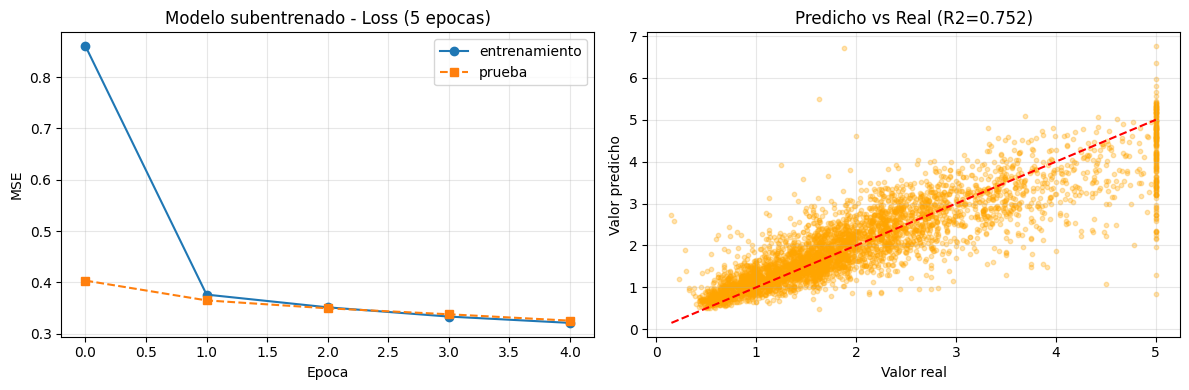

La curva sigue bajando al final, es por la carencia de  epocas
Los puntos naranjas comparados con los azules del commit 2, estan mas dispersos al rededor de la linea roja, especialmente en valores altos. Lo que muestra que el modelo subentrenado no logra predecir bien los precios


In [16]:
# grafico las curvas del modelo subentrenado
# la señal de underfitting es que la curva todavia esta bajando cuando se detiene
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(historia_under.history['loss'], label='entrenamiento', marker='o')
plt.plot(historia_under.history['val_loss'], label='prueba', linestyle='--', marker='s')
plt.title('Modelo subentrenado - Loss (5 epocas)')
plt.xlabel('Epoca')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_test, predicciones_under, alpha=0.3, s=10, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title(f'Predicho vs Real (R2={r2_under:.3f})')
plt.xlabel('Valor real')
plt.ylabel('Valor predicho')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("La curva sigue bajando al final, es por la carencia de  epocas")
print("Los puntos naranjas comparados con los azules del commit 2, estan mas dispersos al rededor de la linea roja, especialmente en valores altos. Lo que muestra que el modelo subentrenado no logra predecir bien los precios")

---
## 4 - Modelo sobreentrenado (Overfitting)

Ahora el caso contrario: Voy a entrenar el mismo modelo con demasiadas épocas (500). El modelo va a memorizar los datos de entrenamiento, incluyendo el ruido, y va a funcionar peor con datos nuevos.

La señal del overfitting es que el error de entrenamiento baja mucho pero el de prueba se separa o sube.

In [17]:
# Modelo sobreentrenado: misma arquitectura pero 500 epocas
modelo_over = crear_modelo()

historia_over = modelo_over.fit(
    X_train, y_train,
    epochs=500,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=0  # Se coloca verbose=0 para no imprimir 500 lineas
)

print("entrenamiento terminado")
print(f"loss final en entrenamiento: {historia_over.history['loss'][-1]:.4f}")
print(f"loss final en prueba:        {historia_over.history['val_loss'][-1]:.4f}")

entrenamiento terminado
loss final en entrenamiento: 0.1703
loss final en prueba:        0.2939


In [18]:
# Prueba del modelo sobreentrenado
predicciones_over = modelo_over.predict(X_test).flatten()

# Tambien hago las evaluaciones en entrenamiento para ver la diferencia
predicciones_over_train = modelo_over.predict(X_train).flatten()

mse_over = mean_squared_error(y_test, predicciones_over)
r2_over = r2_score(y_test, predicciones_over)
r2_over_train = r2_score(y_train, predicciones_over_train)

print("Resultados del modelo sobreentrenado:")
print(f"  R2 en ENTRENAMIENTO: {r2_over_train:.4f}  <-- muy bueno, memorizó")
print(f"  R2 en PRUEBA:        {r2_over:.4f}   <-- peor que en entrenamiento")
print(f"\nEsa diferencia entre los dos R2 es la señal del overfitting")
print(f"Diferencia: {r2_over_train - r2_over:.4f}")

 75/129 ━━━━━━━━━━━━━━━━━━━━ 0s 682us/step

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 999us/step
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 741us/step
Resultados del modelo sobreentrenado:
  R2 en ENTRENAMIENTO: 0.8655  <-- muy bueno, memorizó
  R2 en PRUEBA:        0.7757   <-- peor que en entrenamiento

Esa diferencia entre los dos R2 es la señal del overfitting
Diferencia: 0.0898


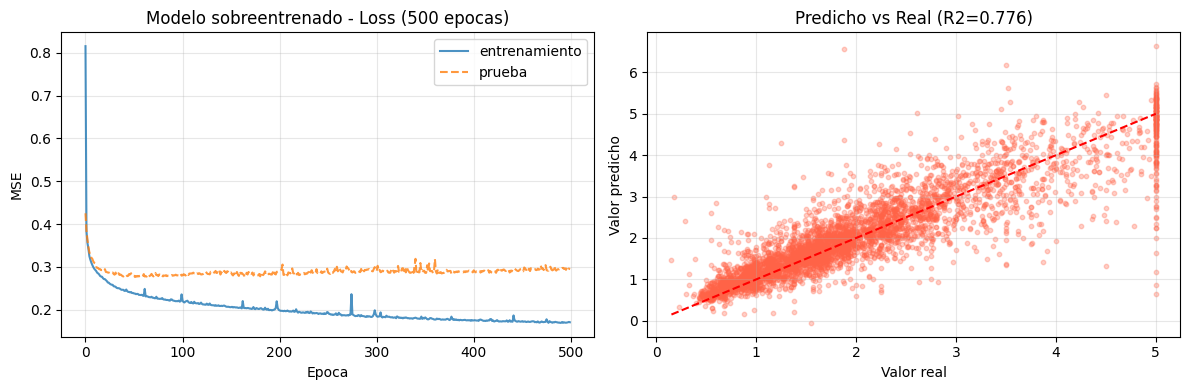

La gran brecha que existe entre las dos curvas, eso es el overfitting


In [19]:
# Grafica de las curvas del modelo sobreentrenado
# La señal del overfitting es la brecha entre la curva de train y la de test
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(historia_over.history['loss'], label='entrenamiento', alpha=0.8)
plt.plot(historia_over.history['val_loss'], label='prueba', linestyle='--', alpha=0.8)
plt.title('Modelo sobreentrenado - Loss (500 epocas)')
plt.xlabel('Epoca')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_test, predicciones_over, alpha=0.3, s=10, color='tomato')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title(f'Predicho vs Real (R2={r2_over:.3f})')
plt.xlabel('Valor real')
plt.ylabel('Valor predicho')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("La gran brecha que existe entre las dos curvas, eso es el overfitting")

---
## Comparacion final de los tres modelos

In [20]:
# Tabla comparativa de los 3 modelos
print("Comparacion de los 3 modelos en datos de PRUEBA")
print("-" * 50)
print(f"{'Modelo':<20} {'Epocas':>8} {'MSE':>10} {'R2':>8}")
print("-" * 50)
print(f"{'Subentrenado':<20} {'5':>8} {mse_under:>10.4f} {r2_under:>8.4f}")
print(f"{'Bien entrenado':<20} {'100':>8} {mse_bueno:>10.4f} {r2_bueno:>8.4f}")
print(f"{'Sobreentrenado':<20} {'500':>8} {mse_over:>10.4f} {r2_over:>8.4f}")
print("-" * 50)
print("\n Como era de esperarse, el modelo bien entrenado tiene el mejor balance entre MSE y R2, mientras que el subentrenado tiene un MSE alto y R2 bajo, y el sobreentrenado tiene un R2 muy bueno en entrenamiento pero mucho peor en prueba")

Comparacion de los 3 modelos en datos de PRUEBA
--------------------------------------------------
Modelo                 Epocas        MSE       R2
--------------------------------------------------
Subentrenado                5     0.3252   0.7518
Bien entrenado            100     0.2719   0.7925
Sobreentrenado            500     0.2939   0.7757
--------------------------------------------------

 Como era de esperarse, el modelo bien entrenado tiene el mejor balance entre MSE y R2, mientras que el subentrenado tiene un MSE alto y R2 bajo, y el sobreentrenado tiene un R2 muy bueno en entrenamiento pero mucho peor en prueba


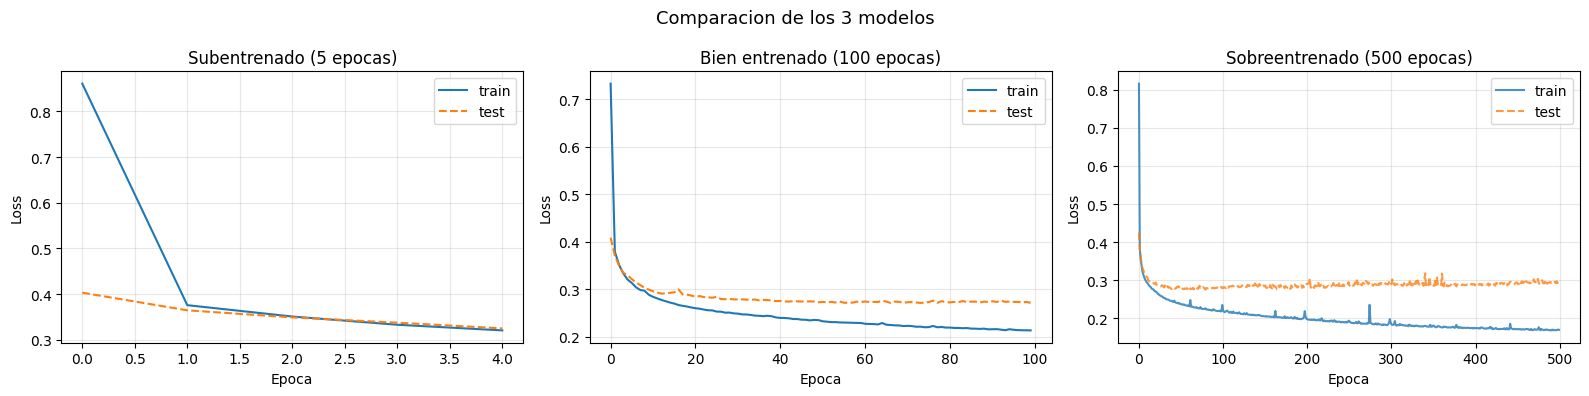

In [21]:
# Comparacion grafica de las curvas de loss de los 3 modelos
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Comparacion de los 3 modelos', fontsize=13)

# Subentrenado
axes[0].plot(historia_under.history['loss'], label='train')
axes[0].plot(historia_under.history['val_loss'], label='test', linestyle='--')
axes[0].set_title('Subentrenado (5 epocas)')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bien entrenado
axes[1].plot(historia_bueno.history['loss'], label='train')
axes[1].plot(historia_bueno.history['val_loss'], label='test', linestyle='--')
axes[1].set_title('Bien entrenado (100 epocas)')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Sobreentrenado
axes[2].plot(historia_over.history['loss'], label='train', alpha=0.8)
axes[2].plot(historia_over.history['val_loss'], label='test', linestyle='--', alpha=0.8)
axes[2].set_title('Sobreentrenado (500 epocas)')
axes[2].set_xlabel('Epoca')
axes[2].set_ylabel('Loss')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Conclusiones

En este pequeño proyecto usé una red neuronal para predecir el precio de casas en California, que es un problema de regresión lineal.

Los tres modelos tienen exactamente la misma arquitectura (64 → 32 → 16 → 1 neuronas). Lo único que cambié fue el número de épocas:

**Modelo subentrenado (5 épocas):** El modelo no tuvo tiempo suficiente para aprender. Las curvas de loss todavía estaban bajando cuando se detuvo el entrenamiento. El error fue alto tanto en entrenamiento como en prueba. Esto es underfitting.

**Modelo bien entrenado (100 épocas):** Las dos curvas de loss bajaron juntas y se estabilizaron en un valor bajo. El R2 fue el mejor de los tres. Este es el punto ideal de entrenamiento.

**Modelo sobreentrenado (500 épocas):** El modelo memorizó los datos de entrenamiento. Se ve la brecha entre la curva de entrenamiento (que sigue bajando) y la de prueba (que se queda estancada o sube). El R2 en entrenamiento fue muy alto pero en datos de prueba fue peor que el modelo bien entrenado. Esto es overfitting.

Los tres modelos tuvieron exactamente la misma arquitectura. La única 
variable que cambié fue el número de épocas. Eso demuestra que no 
basta con diseñar una buena red neuronal también hay que saber 
cuándo detener el entrenamiento. Ese balance es uno de los conceptos 
más importantes en machine learning.